In [ ]:
%cd ../..

In [2]:
import json
import numpy as np
import pandas as pd

def samples_path_to_metrics(samples_path):
    with open(samples_path, "r") as f:
        samples = f.readlines()
    samples = [json.loads(line) for line in samples]
    edit_scores = [sample['edit_score'] for sample in samples]
    aers = [sample['action_error_rate'] for sample in samples]
    def get_rce(sample):
        total_err = sum([sample[f'mae_{p}'] for p in ['idle', 'reach', 'transport', 'reposition', 'stabilize']])
        return total_err / sample['count_truth']
    rces = [get_rce(sample) for sample in samples]

    sample_metrics = pd.DataFrame({
        'edit_score': edit_scores,
        'action_error_rate': aers,
        'relative_counting_error': rces,
    })

    out = {
        "edit_score": np.mean(sample_metrics["edit_score"]),
        "edit_score_std":  np.std(sample_metrics["edit_score"], ddof=1) / np.sqrt(len(sample_metrics)),
        "action_error_rate":        np.mean(sample_metrics["action_error_rate"]),
        "action_error_rate_std":         np.std(sample_metrics["action_error_rate"], ddof=1) / np.sqrt(len(sample_metrics)),
        "relative_counting_error":        np.mean(sample_metrics["relative_counting_error"]),
        "relative_counting_error_std":         np.std(sample_metrics["relative_counting_error"], ddof=1) / np.sqrt(len(sample_metrics)),
    }
    return out

In [3]:
import json
import pandas as pd

def make_latex_table(label_to_path):
    rows = []
    for label, path in label_to_path.items():
        m = samples_path_to_metrics(path)
        rows.append({
            "Model": label,
            "ES": f"{m['edit_score']:.2f} ± {m['edit_score_std']:.2f}",
            "AER": f"{m['action_error_rate']:.2f} ± {m['action_error_rate_std']:.2f}",
            "RCE": f"{m['relative_counting_error']:.2f} ± {m['relative_counting_error_std']:.2f}",
        })
    df = pd.DataFrame(rows)
    return df.to_latex(index=False, escape=False, column_format="lccc", caption="Counting Metrics Comparison")


In [4]:
label_to_path = {
    "PRIM (Full)": "logs/strokerehab_counting/qwen2_5_vl_prim/20251031_224334_results.json",
    "-- w/o cropping": "logs/strokerehab_counting/qwen2_5_vl_prim/20251031_222819_results.json",
    "-- w/o PP": "logs/strokerehab_counting/qwen2_5_vl_prim/20251031_223621_results.json",
    "-- w/o cropping \& PP": "logs/strokerehab_counting/qwen2_5_vl_prim/20251031_222643_results.json",
    "DP (15,4)": "logs/strokerehab_counting/qwen2_5_vl_32b/Qwen__Qwen2.5-VL-32B-Instruct/20251104_091219_results.json",
    "DP": "logs/strokerehab_counting/qwen2_5_vl_32b/Qwen__Qwen2.5-VL-32B-Instruct/20251104_090957_results.json",
}
def results_path_to_samples_path(path):
    return path.replace("_results.json", "_samples_strokerehab_counting.jsonl")
label_to_path = {k: results_path_to_samples_path(v) for k, v in label_to_path.items()}

latex_str = make_latex_table(label_to_path)
print(latex_str)

\begin{table}
\caption{Counting Metrics Comparison}
\begin{tabular}{lccc}
\toprule
Model & ES & AER & RCE \\
\midrule
PRIM (Full) & 67.75 ± 3.26 & 0.42 ± 0.05 & 0.40 ± 0.06 \\
-- w/o cropping & 61.37 ± 3.26 & 0.46 ± 0.05 & 0.45 ± 0.05 \\
-- w/o PP & 50.61 ± 2.90 & 1.04 ± 0.26 & 1.01 ± 0.26 \\
-- w/o cropping \& PP & 44.94 ± 2.81 & 0.79 ± 0.08 & 0.87 ± 0.09 \\
DP (15,4) & 47.29 ± 2.61 & 1.07 ± 0.28 & 1.20 ± 0.31 \\
DP & 55.63 ± 2.57 & 1.00 ± 0.51 & 1.01 ± 0.52 \\
\bottomrule
\end{tabular}
\end{table}



In [5]:
# Get breakdown by patient cohort
from postprocess.primitives.plot_from_log import preds_to_df_from_log

def preds_to_record(pred):
    return {
        "id": pred[0], "edit_score": pred[3]["edit_score"], "action_error_rate": pred[3]["action_error_rate"], "mae_avg": pred[3]["mae_avg"]
    }

import pandas as pd
from data.utils_strokerehab import HEALTHY_PATIENTS, MILD_PATIENTS, MODERATE_PATIENTS, SEVERE_PATIENTS

HEALTHY_PATIENTS = HEALTHY_PATIENTS.split(',')
MILD_PATIENTS = MILD_PATIENTS.split(',')
MODERATE_PATIENTS = MODERATE_PATIENTS.split(',')
SEVERE_PATIENTS = SEVERE_PATIENTS.split(',')

def label_to_agg_metrics(label):
    preds = preds_to_df_from_log(results_path_to_samples_path(label_to_path[label]))
    records = [preds_to_record(pred) for pred in preds]
    df = pd.DataFrame.from_records(records)
    df['patient'] = df['id'].apply(lambda x: x.split('_')[0])
    df['patient_cohort'] = df['patient'].apply(lambda x: 'healthy' if x in HEALTHY_PATIENTS else
                                                'mild' if x in MILD_PATIENTS else
                                                'moderate' if x in MODERATE_PATIENTS else
                                                'severe' if x in SEVERE_PATIENTS else
                                                'unknown')
    metrics_by_patient_cohort = df.groupby('patient_cohort').agg(
        edit_score_mean=('edit_score', 'mean'),
        edit_score_sem=('edit_score', lambda x: x.std() / (len(x) ** 0.5)),
        action_error_rate_mean=('action_error_rate', 'mean'),
        action_error_rate_sem=('action_error_rate', lambda x: x.std() / (len(x) ** 0.5)),
        mae_avg_mean=('mae_avg', 'mean'),
        mae_avg_sem=('mae_avg', lambda x: x.std() / (len(x) ** 0.5)),
    )
    return metrics_by_patient_cohort

In [6]:
label_to_path.keys()

dict_keys(['PRIM (Full)', '-- w/o cropping', '-- w/o PP', '-- w/o cropping \\& PP', 'DP (15,4)', 'DP'])

In [7]:
label_to_agg_metrics("DP")

,edit_score_mean,edit_score_sem,action_error_rate_mean,action_error_rate_sem,mae_avg_mean,mae_avg_sem
patient_cohort,,,,,,
healthy,53.761653,2.999442,0.474787,0.027042,5.600,0.644291
mild,66.385169,4.267858,0.355067,0.045671,3.580,0.451614
moderate,59.420570,3.226340,0.457133,0.055146,5.500,1.064686
severe,39.801319,6.784702,3.133584,2.412312,5.675,0.817608


In [8]:
from typing import Dict, Tuple

cohort_style: Dict[str, Tuple[str, str]] = {
    "Healthy":  ("#649FC7", "D"),  # dark blue
    "Mild":     ("#6F64D4", "o"),  # violet
    "Moderate": ("#C2288C", "o"),  # rosy pink
    "Severe":   ("#9C1A00", "o"),  # brick red
}

In [9]:
from postprocess.primitives.plot_from_log import preds_to_df_from_log
samples_path = "logs/strokerehab_counting/qwen2_5_vl_prim/20251031_224334_samples_strokerehab_counting.jsonl"
preds = preds_to_df_from_log(samples_path)
# x[3] has the metrics
counts = [(x[0], x[1]['label'].value_counts(), x[2]['label'].value_counts()) for x in preds]
labels = ["IDLE", "REACH", "REPOSITION", "TRANSPORT", "STABILIZE"]
def series_to_counts(series, labels):
    return [series.get(label, 0) for label in labels]


In [10]:
ids_col = []
labels_col = []
counts_pred_col = []
counts_true_col = []
for c in counts:
    count_pred = series_to_counts(c[1], labels)
    count_true = series_to_counts(c[2], labels)
    for lab, cp, ct in zip(labels, count_pred, count_true):
        ids_col.append(c[0])
        labels_col.append(lab)
        counts_pred_col.append(cp)
        counts_true_col.append(ct)
df = pd.DataFrame({
    "id": ids_col,
    "label": labels_col,
    "count_pred": counts_pred_col,
    "count_true": counts_true_col
})


from data.utils_strokerehab import HEALTHY_PATIENTS, MILD_PATIENTS, MODERATE_PATIENTS, SEVERE_PATIENTS
healthy = HEALTHY_PATIENTS.split(',')
mild = MILD_PATIENTS.split(',')
moderate = MODERATE_PATIENTS.split(',')
severe = SEVERE_PATIENTS.split(',')
def patient_to_cohort(patient_id):
    if patient_id in healthy:
        return "Healthy"
    elif patient_id in mild:
        return "Mild"
    elif patient_id in moderate:
        return "Moderate"
    elif patient_id in severe:
        return "Severe"
    else:
        return "Unknown"

df['patient'] = df['id'].apply(lambda x: x.split('_')[0])
df['patient_cohort'] = df['patient'].apply(patient_to_cohort)
df.drop('patient', axis=1, inplace=True)

In [11]:
df.columns

Index(['id', 'label', 'count_pred', 'count_true', 'patient_cohort'], dtype='object')

In [12]:
from collections import defaultdict
rces_by_cohort = defaultdict(list)
for id_ in df['id'].unique():
    df_id = df[df['id'] == id_]
    rce = ((df_id['count_pred'] - df_id['count_true']).abs().sum()) / df_id['count_true'].sum()
    rces_by_cohort[df_id['patient_cohort'].iloc[0]].append(rce)

In [13]:
# Calculate means and standard errors
rce_stats_by_cohort = {}
for cohort, rces in rces_by_cohort.items():
    mean_rce = np.mean(rces)
    sem_rce = np.std(rces, ddof=1) / np.sqrt(len(rces))
    rce_stats_by_cohort[cohort[0].upper() + cohort[1:]] = (mean_rce, sem_rce)

In [14]:
rce_stats_by_cohort

{'Healthy': (0.209062838517369, 0.05547931592693023),
 'Moderate': (0.5479313353750153, 0.1257657252711198),
 'Mild': (0.2313827252571171, 0.044417961924286146),
 'Severe': (0.6552825003392154, 0.15903018962892607)}

In [15]:
df.head()

,id,label,count_pred,count_true,patient_cohort
0,C00022_RTT left side1_2,IDLE,18,17,Healthy
1,C00022_RTT left side1_2,REACH,17,15,Healthy
2,C00022_RTT left side1_2,REPOSITION,17,15,Healthy
3,C00022_RTT left side1_2,TRANSPORT,10,14,Healthy
4,C00022_RTT left side1_2,STABILIZE,1,0,Healthy


In [16]:
def rcep(x):
    return ((x['count_pred'] - x['count_true']).abs().sum()) / x['count_true'].sum()

avg_ppce = df.groupby('label')[['count_pred', 'count_true']].apply(lambda x: rcep(x))

REACH
REPOSITION
TRANSPORT
STABILIZE
IDLE


/tmp/ipykernel_2624318/2589126122.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


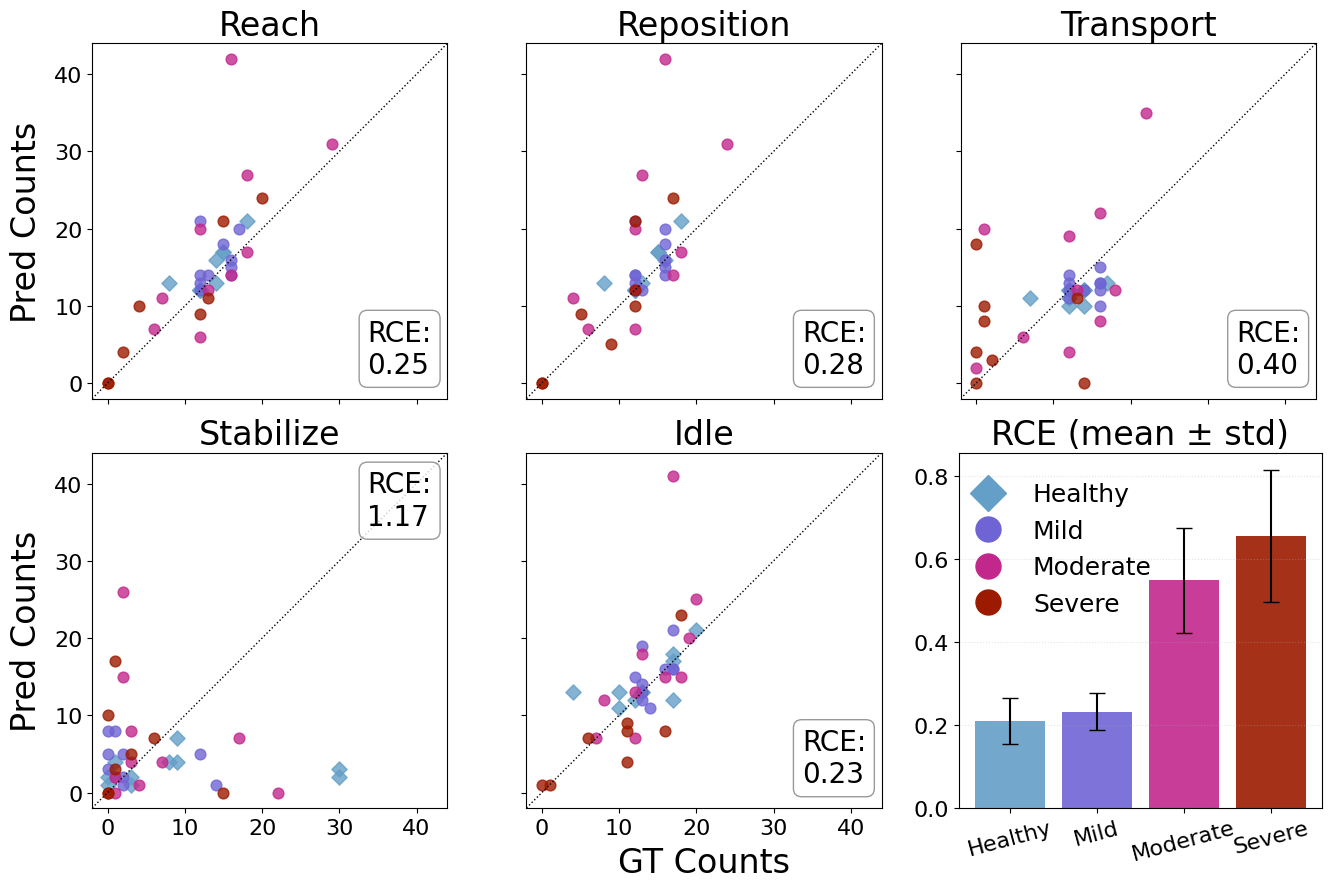

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D
from typing import Dict, Tuple, List, Optional


def plot_repetition_counts_with_rce(
    df: pd.DataFrame,
    rce_stats_by_cohort: Dict[str, Tuple[float, float]],  # {'Healthy': (mean, sd), ...}
    cohort_style: Dict[str, Tuple[str, str]],             # {'healthy': ('#649FC7', 'D'), ...}
    labels: List[str] = ("REACH", "REPOSITION", "TRANSPORT", "STABILIZE", "IDLE"),
    save_fig: Optional[str] = "repetition_counts_scatter.pdf",
    figsize: Tuple[int, int] = (14, 9)
):
    """
    Make 2x3 panel:
      - First 5 cells: scatter of GT vs Pred counts for each primitive (shared axes).
      - Bottom-right cell: independent RCE bar chart (mean ± sd) with a tiny marker legend.
    The RCE panel is overlaid AFTER tight_layout to avoid altering shared axis limits.

    Args
    ----
    df : DataFrame with columns ['label', 'patient_cohort', 'count_true', 'count_pred'].
         patient_cohort values should match keys of cohort_style (lowercase).
    rce_stats_by_cohort : dict like {'Healthy': (mean, sd), 'Mild': (...), ...}.
    cohort_style : dict mapping lowercase cohort -> (color, marker).
    labels : sequence of primitive names (first 5 will be plotted).
    save_fig : optional path to save the figure (set None to skip saving).
    figsize : figure size.
    """
    # ---- figure & shared axes for the 5 scatters ----
    fig, axes = plt.subplots(2, 3, figsize=figsize, sharex=True, sharey=True)
    axes = axes.flatten()

    # Shared limits for the scatters
    max_ct = float(max(df["count_true"].max(), df["count_pred"].max()))
    lim = [-2, max_ct + 2]

    # Plot the five scatter subplots
    for i, label in enumerate(labels[:5]):
        ax = axes[i]
        ax.set_aspect('equal', adjustable='box')
        g = df[df["label"] == label]

        for cohort, (color, marker) in cohort_style.items():
            sub = g[g["patient_cohort"] == cohort]
            if not sub.empty:
                ax.scatter(
                    sub["count_true"], sub["count_pred"],
                    label=cohort.capitalize(), color=color, marker=marker,
                    s=60, alpha=0.8
                )

        ax.plot(lim, lim, "k:", lw=1)
        ax.set_xlim(lim)
        ax.set_ylim(lim)
        ax.set_title(label.capitalize(), fontsize=24)
        ax.tick_params(axis='both', labelsize=16)

        if i == 0 or i == 3:
            ax.set_ylabel("Pred Counts", fontsize=24, labelpad=8)
        if i == 4:  # bottom-center
            ax.set_xlabel("GT Counts", fontsize=24, labelpad=6)
        
        print(label)
        if i == 3:
            ax.text(0.775, 0.95, f"RCE:\n{avg_ppce[label]:.2f}",
                    transform=ax.transAxes, fontsize=20, va="top", ha="left",
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8)
            )
        else:
            ax.text(0.775, 0.225, f"RCE:\n{avg_ppce[label]:.2f}",
                    transform=ax.transAxes, fontsize=20, va="top", ha="left",
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))


    # --- Reserve bottom-right subplot (do NOT change shared limits) ---
    legend_host = axes[-1]
    legend_host.set_visible(False)  # hides its contents, keeps ticks elsewhere intact

    # --- After plotting and just before plt.show() ---
    plt.tight_layout()
    fig.canvas.draw()  # lock in final layout positions

    # Create an independent axes over the bottom-right cell
    pos = legend_host.get_position(fig)
    ax_rce = fig.add_axes([pos.x0+0.01, pos.y0, pos.width-0.04, pos.height])  # same size

    # Draw RCE bars
    cohort_names = [k.capitalize() for k in cohort_style.keys()]
    means = [rce_stats_by_cohort[c][0] for c in cohort_names]
    errs  = [rce_stats_by_cohort[c][1] for c in cohort_names]
    cols  = [cohort_style[c][0] for c in cohort_names]

    x = np.arange(len(cohort_names))
    ax_rce.bar(x, means, yerr=errs, capsize=6, alpha=0.9, color=cols)

    # Formatting
    ax_rce.set_title("RCE (mean ± std)", fontsize=24, pad=6)
    ax_rce.set_xticks(x)
    ax_rce.set_xticklabels(cohort_names, fontsize=16, rotation=15)
    ax_rce.tick_params(axis='y', labelsize=16)
    ax_rce.grid(axis="y", linestyle=":", alpha=0.35)

    # Tiny marker legend
    from matplotlib.lines import Line2D
    handles = [
        Line2D([], [], linestyle="None", marker=cohort_style[c][1],
            color=cohort_style[c][0], markersize=18, label=c)
        for c in cohort_names
    ]
    ax_rce.legend(handles=handles, frameon=False, fontsize=18,
                loc="upper left", bbox_to_anchor=(-0.05, 0.98))

    plt.tight_layout()
    if save_fig:
        fig.savefig(save_fig, bbox_inches='tight', dpi=300)
    plt.show()

plot_repetition_counts_with_rce(
    df,
    rce_stats_by_cohort,
    cohort_style,
    save_fig="repetition_counts_scatter.pdf"
)